<a href="https://colab.research.google.com/github/kasinadhsarma1/Notebooks/blob/main/codegraph_qa_graphsmith_draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CodeGraph-QA & GraphSmith — draft research notebook

**Paper:** *CodeGraph-QA and GraphSmith: Measuring and Training Structural Reasoning for Local Software-Engineering Agents* (Kaggle Gemma 4 Developer Agent — Paper Track)
**Author:** Kasinadh Sarma · kasinadhsarma@gmail.com · License: Apache 2.0

> ⚠️ **Draft.** This notebook produces every number that replaces a red **TBD** in the paper. Numbers produced in `MODE="toy"` or with the `oracle` / `random` backends are **pipeline checks only** and must never go into the paper.

**What this notebook does**

| § | Section | Paper link |
|---|---|---|
| 1 | Configuration | — |
| 2 | Data: competition loader (schema-tolerant) or built-in toy repository | §III |
| 3 | Graph utilities | §III |
| 4 | CodeGraph-QA generator (5 task families, hop-stratified) | §IV, Table I |
| 5 | Graph encoders $E_{adj}, E_{inc}, E_{tree}, E_{json}, E_{tool}$ | §IV |
| 6 | Model backends (oracle / random / OpenAI-compatible vLLM) | §VII |
| 7 | Scoring and the evaluation matrix | Table II, H1–H2 |
| 8 | GraphSmith: centrality, mutation, 3-gate verification | §V, Fig. 2 |
| 9 | Hybrid retrieval ($\alpha$ sweep) | H4 |
| 10 | Security slice (dual oracle) | §VI, Table III |
| 11 | End-to-end predictive validity | H3 |
| 12 | Statistics helpers & LaTeX export | §VII |
| 13 | Dataset export & data card | §X |
| 14 | Figures (PNG + PDF) | Tables II–III, Figs. |
| 15 | Save everything & download (zip) | — |

**Run order:** first run everything with `MODE="toy"` and `BACKEND="oracle"` (all QA scores should be 1.0 — this validates labels and scoring), then `BACKEND="random"` (a floor), then switch to `MODE="competition"` and `BACKEND="openai_compat"` with a vLLM server running the competition checkpoint.

## 1. Configuration

In [1]:
from pathlib import Path
import os

MODE = "toy"             # "toy" | "competition"
BACKEND = "oracle"       # "oracle" | "random" | "openai_compat"

# OpenAI-compatible server, e.g. `vllm serve google/gemma-4-31B-it-qat-w4a16-ct --max-model-len 32768`
OPENAI_BASE_URL = os.environ.get("OPENAI_BASE_URL", "http://localhost:8000/v1")
MODEL_ID = "google/gemma-4-31B-it-qat-w4a16-ct"
TEMPERATURE, TOP_P, MAX_TOKENS = 0.0, 1.0, 1024

SEEDS = [0, 1, 2]
HOPS = [1, 2, 3, 4]
N_PER_STRATUM = 25          # questions per (family, k) per repository
TOKEN_BUDGET = 6000         # matched prompt budget for static encodings (approx.)
TOOL_BUDGET = 12            # max tool calls for E_tool
ANSWER_CAP = 30             # resample questions whose answer set is larger
ENCODINGS = ["adj", "inc", "tree", "json", "tool"]
FAMILIES = ["neighborhood", "reachability", "path", "localization", "concordance"]

RUN_GRAPHSMITH = True
GRAPHSMITH_MAX_CANDIDATES = 200          # mutation attempts (pytest runs) per repository
GS_TIER_CAP = {1: 15, 2: 15, 3: 15}  # max kept instances per difficulty bin k (3 = 3+; k >= 1 because tests are never the defect)
ISSUE_REDACTION = "message"              # "none" | "message" (realistic default) | "full" (also rewrites test names)
GS_EVAL_REDACTIONS = ["message", "full"] # levels evaluated in the leak-aware table
FLAKY_RERUNS = 3
TEST_TIMEOUT = 120          # seconds per pytest call

WORK = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./work")
WORK = WORK.resolve()
WORK.mkdir(parents=True, exist_ok=True)
print("MODE:", MODE, "| BACKEND:", BACKEND, "| WORK:", WORK.resolve())

MODE: toy | BACKEND: oracle | WORK: /content/work


In [2]:
import ast, hashlib, json, math, random, re, shutil, subprocess, sys, tarfile, textwrap, zipfile, time
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict, deque
from copy import deepcopy

import numpy as np
import pandas as pd
import networkx as nx
from scipy import stats

def set_seed(s):
    random.seed(s); np.random.seed(s)

def assert_unique_ids(items, name):
    dup = [i for i, c in Counter(x["id"] for x in items).items() if c > 1]
    assert not dup, f"{name}: {len(dup)} duplicate ids, e.g. {dup[:3]} — results would be double-counted."
    print(f"✅ {name}: {len(items)} items, all ids unique.")
set_seed(0)

## 2. Data

### 2a. Built-in toy repository
A tiny HTTP-style package with tests. It lets every stage — including GraphSmith's execution gates — run end to end without the competition data. **Toy results are not paper results.**

In [3]:
TOY_FILES = {
"minihttp/__init__.py": "",
"minihttp/headers.py": """
def validate_header_value(value):
    if "\\n" in value or "\\r" in value:
        raise ValueError("invalid header value")
    return value


def normalize_header_name(name):
    return name.strip().title()


def merge_headers(base, extra):
    merged = {normalize_header_name(k): validate_header_value(v) for k, v in base.items()}
    for k, v in extra.items():
        merged[normalize_header_name(k)] = validate_header_value(v)
    return merged
""",
"minihttp/urls.py": """
def split_scheme(url):
    if "://" not in url:
        raise ValueError("missing scheme")
    scheme, rest = url.split("://", 1)
    return scheme.lower(), rest


def normalize_host(host):
    host = host.lower()
    if host.endswith("."):
        host = host[:-1]
    return host


def parse_url(url):
    scheme, rest = split_scheme(url)
    host, _, path = rest.partition("/")
    port = 443 if scheme == "https" else 80
    if ":" in host:
        host, port_s = host.split(":", 1)
        port = int(port_s)
        if port <= 0 or port > 65535:
            raise ValueError("bad port")
    return {"scheme": scheme, "host": normalize_host(host), "port": port, "path": "/" + path}


def encode_params(params):
    parts = []
    for key in sorted(params):
        parts.append(f"{key}={params[key]}")
    return "&".join(parts)
""",
"minihttp/client.py": """
from .urls import parse_url, encode_params
from .headers import merge_headers

DEFAULT_HEADERS = {"user-agent": "minihttp/0.1"}


class Request:
    def __init__(self, method, url, headers=None, params=None):
        self.method = method.upper()
        self.url = parse_url(url)
        self.headers = merge_headers(DEFAULT_HEADERS, headers or {})
        self.query = encode_params(params or {})

    def target(self):
        if self.query:
            return self.url["path"] + "?" + self.query
        return self.url["path"]


def build_request(method, url, headers=None, params=None):
    if method.upper() not in ("GET", "POST", "PUT", "DELETE"):
        raise ValueError("unsupported method")
    return Request(method, url, headers, params)


def render_request(request):
    lines = [f"{request.method} {request.target()} HTTP/1.1", f"Host: {request.url['host']}"]
    for name, value in request.headers.items():
        lines.append(f"{name}: {value}")
    return "\\r\\n".join(lines) + "\\r\\n\\r\\n"


def get(url, **kwargs):
    return render_request(build_request("GET", url, **kwargs))
""",
"tests/__init__.py": "",
"tests/test_urls.py": """
import pytest
from minihttp.urls import parse_url, encode_params, split_scheme


def test_scheme_required():
    with pytest.raises(ValueError):
        split_scheme("example.com")


def test_default_ports():
    assert parse_url("https://a.com/x")["port"] == 443
    assert parse_url("http://a.com/x")["port"] == 80


def test_explicit_port_bounds():
    assert parse_url("http://a.com:65535/")["port"] == 65535
    with pytest.raises(ValueError):
        parse_url("http://a.com:0/")


def test_host_normalized():
    assert parse_url("http://A.COM./p")["host"] == "a.com"


def test_params_sorted():
    assert encode_params({"b": 2, "a": 1}) == "a=1&b=2"
""",
"tests/test_headers.py": """
import pytest
from minihttp.headers import merge_headers, validate_header_value


def test_crlf_rejected():
    with pytest.raises(ValueError):
        validate_header_value("x\\r\\nInjected: 1")


def test_merge_titlecases():
    assert merge_headers({"x-a": "1"}, {"x-b": "2"}) == {"X-A": "1", "X-B": "2"}
""",
"tests/test_client.py": """
import pytest
from minihttp.client import build_request, get


def test_get_renders_host_and_target():
    out = get("http://a.com/p", params={"q": "1"})
    assert out.startswith("GET /p?q=1 HTTP/1.1\\r\\nHost: a.com")


def test_default_user_agent():
    assert "User-Agent: minihttp/0.1" in get("http://a.com/")


def test_method_validation():
    with pytest.raises(ValueError):
        build_request("BREW", "http://a.com/")


def test_header_injection_blocked():
    with pytest.raises(ValueError):
        get("http://a.com/", headers={"X": "a\\r\\nB: c"})
""",
}

def write_toy_repo(root: Path):
    if root.exists():
        shutil.rmtree(root)
    for rel, src in TOY_FILES.items():
        p = root / rel
        p.parent.mkdir(parents=True, exist_ok=True)
        p.write_text(src.lstrip("\n"))
    return root

### 2b. AST graph builder
Used for the toy repository and for regenerating graphs on extra repositories (out-of-distribution check). Nodes: modules, classes, functions/methods, tests. Edges: `contains`, `calls`, `imports`, `inherits`. The competition graphs are loaded as-is in 2c; this builder only mirrors their shape.

In [4]:
def _qual(module, *parts):
    return ".".join([module, *[p for p in parts if p]])

def build_graph_from_repo(repo: Path, include_tests=True):
    G = nx.MultiDiGraph()
    files = sorted(p for p in repo.rglob("*.py") if include_tests or "tests" not in p.parts)
    defs_by_name = defaultdict(set)
    pending_calls, pending_imports, pending_bases = [], [], []
    for f in files:
        rel = f.relative_to(repo).as_posix()
        module = rel[:-3].replace("/", ".").removesuffix(".__init__")
        src = f.read_text()
        tree = ast.parse(src)
        lines = src.splitlines()
        G.add_node(module, kind="module", name=module.split(".")[-1], file=rel,
                   lineno=1, end_lineno=len(lines), source=src[:2000])
        def visit(node, scope, parent_id, cls=None):
            for ch in ast.iter_child_nodes(node):
                if isinstance(ch, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)):
                    qid = _qual(module, *scope, ch.name)
                    is_test = rel.startswith("tests/") and ch.name.startswith("test_")
                    kind = "class" if isinstance(ch, ast.ClassDef) else ("test" if is_test else ("method" if cls else "function"))
                    G.add_node(qid, kind=kind, name=ch.name, file=rel, lineno=ch.lineno,
                               end_lineno=ch.end_lineno, source=ast.get_source_segment(src, ch) or "")
                    G.add_edge(parent_id, qid, type="contains")
                    defs_by_name[ch.name].add(qid)
                    if isinstance(ch, ast.ClassDef):
                        for b in ch.bases:
                            if isinstance(b, ast.Name):
                                pending_bases.append((qid, b.id))
                        visit(ch, scope + [ch.name], qid, cls=qid)
                    else:
                        for sub in ast.walk(ch):
                            if isinstance(sub, ast.Call):
                                fn = sub.func
                                name = fn.id if isinstance(fn, ast.Name) else (fn.attr if isinstance(fn, ast.Attribute) else None)
                                if name:
                                    pending_calls.append((qid, name))
                        visit(ch, scope + [ch.name], qid, cls=cls)
        visit(tree, [], module)
        for node in ast.walk(tree):
            if isinstance(node, ast.ImportFrom) and node.module is not None:
                base = node.module
                if node.level:
                    pkg = module.split(".")[: len(module.split(".")) - node.level] if not rel.endswith("__init__.py") else module.split(".")[: len(module.split(".")) - node.level + 1]
                    base = ".".join(pkg + [node.module])
                for a in node.names:
                    pending_imports.append((module, base, a.name))
    for caller, name in pending_calls:
        targets = defs_by_name.get(name, set())
        if len(targets) == 1:
            t = next(iter(targets))
            if G.nodes[t]["kind"] == "class":
                init = t + ".__init__"
                G.add_edge(caller, t, type="calls")
                if init in G:
                    G.add_edge(caller, init, type="calls")
            elif t != caller:
                G.add_edge(caller, t, type="calls")
    for mod, base, name in pending_imports:
        tgt = f"{base}.{name}"
        if tgt in G:
            G.add_edge(mod, tgt, type="imports")
        elif base in G:
            G.add_edge(mod, base, type="imports")
    for cls, base in pending_bases:
        for t in defs_by_name.get(base, ()):
            if G.nodes[t]["kind"] == "class":
                G.add_edge(cls, t, type="inherits")
    return G

def hashed_embeddings(G, dim=256):
    """Deterministic stand-in for the provided 256-d embeddings (toy mode only)."""
    E = {}
    for n, d in G.nodes(data=True):
        v = np.zeros(dim, dtype=np.float32)
        for tok in re.findall(r"[A-Za-z_]{3,}", (d.get("name", "") + " " + d.get("source", "")).lower()):
            h = int(hashlib.md5(tok.encode()).hexdigest(), 16)
            v[h % dim] += 1.0 if (h >> 8) % 2 else -1.0
        E[n] = v / (np.linalg.norm(v) + 1e-9)
    return E

### 2c. Competition data loader (schema-tolerant)
The graph serialization, node/edge attribute names and embedding ID mapping are **not yet confirmed** from the Kaggle data tab. The loader tries common formats, normalizes attribute names, and prints a schema inventory — record that inventory in the data card. Adjust `graph_file_for_task` / `embedding_files_for_task` once you have seen the real file names.

In [5]:
def find_competition_root():
    roots = [Path("/kaggle/input/gemma-4-developer-agent")] + sorted(Path("/kaggle/input").glob("*gemma*")) \
            if Path("/kaggle/input").exists() else [Path("./data")]
    for r in roots:
        hits = list(r.rglob("tasks.jsonl")) if r.exists() else []
        if hits:
            return hits[0].parent
    raise FileNotFoundError("tasks.jsonl not found — attach the competition dataset or set the path manually.")

def load_tasks(root):
    return [json.loads(l) for l in (root / "tasks.jsonl").read_text().splitlines() if l.strip()]

def task_id(t):
    return t.get("instance_id") or t.get("task_id") or t.get("id")

def graph_file_for_task(root, t):
    tid = task_id(t)
    cands = [p for p in (root / "graphs").rglob("*") if p.is_file() and tid and tid in p.name]
    if not cands:
        repo = (t.get("repo") or "").replace("/", "__")
        cands = [p for p in (root / "graphs").rglob("*") if p.is_file() and repo and repo in p.name]
    return cands[0] if cands else None

def embedding_files_for_task(root, t):
    tid = task_id(t)
    d = root / "embeddings"
    vecs = [p for p in d.rglob("*.npy") if tid in p.name] if d.exists() else []
    ids = [p for p in d.rglob("*") if tid in p.name and p.suffix in (".json", ".txt", ".jsonl")] if d.exists() else []
    return (vecs[0] if vecs else None), (ids[0] if ids else None)

NODE_KEYS = {"kind": ["kind", "type", "node_type", "category"],
             "name": ["name", "short_name", "label"],
             "file": ["file", "path", "filepath", "file_path"],
             "lineno": ["lineno", "start_line", "line", "start"],
             "end_lineno": ["end_lineno", "end_line", "end"],
             "source": ["source", "code", "definition", "text"]}
EDGE_KEYS = ["type", "relation", "rel", "label", "edge_type", "key"]

def _normalize(G):
    H = nx.MultiDiGraph()
    for n, d in G.nodes(data=True):
        nd = {k: next((d[a] for a in alts if a in d), None) for k, alts in NODE_KEYS.items()}
        nd["name"] = nd["name"] or str(n).split(".")[-1]
        nd["kind"] = (nd["kind"] or "symbol").lower()
        nd["source"] = nd["source"] or ""
        H.add_node(str(n), **nd)
    for u, v, k, d in G.edges(keys=True, data=True):
        et = next((d[a] for a in EDGE_KEYS if a in d), None) or (k if isinstance(k, str) else "related")
        H.add_edge(str(u), str(v), type=str(et).lower())
    return H

def load_graph(path: Path):
    s = path.suffix.lower()
    if s == ".json":
        data = json.loads(path.read_text())
        edges_key = "links" if "links" in data else "edges"
        G = nx.node_link_graph(data, directed=True, multigraph=True, edges=edges_key)
    elif s == ".graphml":
        G = nx.read_graphml(path)
    elif s == ".gexf":
        G = nx.read_gexf(path)
    elif s in (".pkl", ".pickle", ".gpickle"):
        import pickle
        G = pickle.loads(path.read_bytes())
    else:
        raise ValueError(f"Unknown graph format: {path}")
    return _normalize(G)

def load_embeddings(vec_path, ids_path, G):
    X = np.load(vec_path).astype(np.float32)
    if ids_path is None:
        ids = list(G.nodes())
        assert len(ids) == len(X), "No id file and row count != node count — fix the mapping."
    elif ids_path.suffix == ".json":
        ids = json.loads(ids_path.read_text())
    else:
        ids = [l.strip() for l in ids_path.read_text().splitlines() if l.strip()]
    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)
    return {str(i): X[j] for j, i in enumerate(ids)}

def schema_inventory(G, E=None):
    return {"nodes": G.number_of_nodes(), "edges": G.number_of_edges(),
            "node_kinds": dict(Counter(d["kind"] for _, d in G.nodes(data=True))),
            "edge_types": dict(Counter(d["type"] for *_, d in G.edges(data=True))),
            "embedding_coverage": None if E is None else round(sum(n in E for n in G) / max(1, len(G)), 3)}

### 2d. Assemble the corpus

In [6]:
# Each corpus entry: repo name -> dict(G=graph, E=embeddings, tasks=[...], repo_dir=path or None)
CORPUS = {}
if MODE == "toy":
    toy_dir = write_toy_repo(WORK / "toy_repo")
    G = build_graph_from_repo(toy_dir)
    CORPUS["toy/minihttp"] = dict(G=G, E=hashed_embeddings(G), tasks=[], repo_dir=toy_dir)
else:
    ROOT = find_competition_root()
    TASKS = load_tasks(ROOT)
    print(len(TASKS), "tasks | fields:", sorted(TASKS[0].keys()))
    for t in TASKS:
        gp = graph_file_for_task(ROOT, t)
        if gp is None:
            print("no graph for", task_id(t)); continue
        G = load_graph(gp)
        vp, ip = embedding_files_for_task(ROOT, t)
        E = load_embeddings(vp, ip, G) if vp else {}
        key = task_id(t)   # one graph per task snapshot
        CORPUS[key] = dict(G=G, E=E, tasks=[t], repo_dir=None, repo=t.get("repo"))

for k, v in list(CORPUS.items())[:5]:
    print(k, schema_inventory(v["G"], v["E"]))

toy/minihttp {'nodes': 32, 'edges': 61, 'node_kinds': {'module': 8, 'class': 1, 'method': 2, 'function': 10, 'test': 11}, 'edge_types': {'contains': 24, 'imports': 10, 'calls': 27}, 'embedding_coverage': 1.0}


## 3. Graph utilities

In [7]:
SYMBOL_KINDS = {"function", "method", "class", "symbol"}

def typed_digraph(G, types):
    D = nx.DiGraph()
    D.add_nodes_from(G.nodes(data=True))
    D.add_edges_from((u, v) for u, v, d in G.edges(data=True) if d["type"] in types)
    return D

def neighbors_by_type(G, v):
    out = defaultdict(set)
    for _, w, d in G.out_edges(v, data=True):
        out[d["type"] + "_out"].add(w)
    for u, _, d in G.in_edges(v, data=True):
        out[d["type"] + "_in"].add(u)
    return out

def symbols(G, include_tests=False):
    return [n for n, d in G.nodes(data=True)
            if d["kind"] in SYMBOL_KINDS or (include_tests and d["kind"] == "test")]

def degree_tercile(G, nodes):
    deg = {n: G.degree(n) for n in nodes}
    qs = np.quantile(list(deg.values()) or [0], [1/3, 2/3])
    return {n: int(deg[n] > qs[0]) + int(deg[n] > qs[1]) for n in nodes}

def exact_k_sets(D, source, kmax):
    """Nodes at exactly distance k from source in D (BFS)."""
    dist = nx.single_source_shortest_path_length(D, source, cutoff=kmax)
    rings = defaultdict(set)
    for n, k in dist.items():
        if k > 0:
            rings[k].add(n)
    return rings, dist

# --- unified-diff -> defect set D(p) ---------------------------------------
def diff_modified_lines(patch: str):
    """Return {file: set(original line numbers touched)} from a unified diff."""
    out, cur, old = defaultdict(set), None, 0
    for line in patch.splitlines():
        if line.startswith("--- "):
            cur = line[4:].strip().removeprefix("a/")
        elif line.startswith("@@"):
            m = re.match(r"@@ -(\d+)(?:,(\d+))? \+", line)
            old = int(m.group(1))
        elif cur and line.startswith("-") and not line.startswith("---"):
            out[cur].add(old); old += 1
        elif cur and line.startswith("+") and not line.startswith("+++"):
            out[cur].add(max(old - 1, 1))
        elif cur and line.startswith(" "):
            old += 1
    return out

def defect_set(G, patch):
    mod = diff_modified_lines(patch)
    hits = set()
    for n, d in G.nodes(data=True):
        if d["kind"] not in SYMBOL_KINDS or not d.get("file") or d.get("lineno") is None:
            continue
        for f, lines in mod.items():
            if str(d["file"]).endswith(f) or f.endswith(str(d["file"])):
                lo, hi = int(d["lineno"]), int(d.get("end_lineno") or d["lineno"])
                if any(lo <= l <= hi for l in lines):
                    hits.add(n)
    # keep the innermost symbols (drop a class if one of its methods is hit)
    return {n for n in hits if not any(m != n and m.startswith(n + ".") for m in hits)}

def mention_set(G, text):
    toks = set(re.findall(r"[A-Za-z_][A-Za-z0-9_\.]{3,}", text or ""))
    short = {t.split(".")[-1] for t in toks}
    return {n for n, d in G.nodes(data=True)
            if d["kind"] in SYMBOL_KINDS and (n in toks or (d["name"] in short and len(d["name"]) >= 4))}

## 4. CodeGraph-QA generator
Five families (paper Table I). Labels come from the graph only; the gold patch is used solely to compute localization labels and never enters a prompt. Sampling is stratified by degree tercile and hop stratum $k$.

In [8]:
def _mk(family, repo, k, question, answer, focus, **extra):
    uid = hashlib.sha1(f"{repo}|{family}|{k}|{question}".encode()).hexdigest()[:12]
    return dict(id=f"{family[:3]}-{uid}", family=family, repo=repo, k=k,
                question=question, answer=answer, focus=list(focus), **extra)

def gen_neighborhood(repo, G, n, rng):
    out, nodes = [], symbols(G)
    rng.shuffle(nodes)
    for v in nodes:
        nb = neighbors_by_type(G, v)
        rel = next((r for r in ["calls_out", "calls_in", "imports_in", "contains_out"] if nb.get(r)), None)
        if rel is None or len(nb[rel]) > ANSWER_CAP:
            continue
        verb = {"calls_out": "calls directly", "calls_in": "directly call it",
                "imports_in": "import it", "contains_out": "it contains"}[rel]
        q = (f"List every symbol that {verb}: `{v}`." if rel == "calls_out"
             else f"List every symbol that {verb}, for `{v}`." if rel != "contains_out"
             else f"List every symbol that `{v}` contains.")
        out.append(_mk("neighborhood", repo, 1, q, sorted(nb[rel]), [v], relation=rel))
        if len(out) >= n:
            break
    return out

def gen_reachability(repo, G, n, rng):
    R = typed_digraph(G, {"calls"}).reverse(copy=True)   # callers of v = affected by v's signature change
    out = []
    for k in HOPS:
        nodes = symbols(G); rng.shuffle(nodes); got = 0
        for v in nodes:
            rings, dist = exact_k_sets(R, v, k)
            if not rings.get(k):
                continue                                   # depth k must add something
            ans = sorted(u for u, d in dist.items() if 0 < d <= k)
            if len(ans) > ANSWER_CAP:
                continue
            q = (f"If the signature of `{v}` changes, list every symbol that could be affected "
                 f"through call relationships within {k} hop(s) (callers, callers of callers, ...).")
            out.append(_mk("reachability", repo, k, q, ans, [v])); got += 1
            if got >= n:
                break
    return out

def gen_path(repo, G, n, rng):
    D = typed_digraph(G, {"calls"})
    out = []
    for k in HOPS:
        pairs = []
        for s in D.nodes():
            for t, d in nx.single_source_shortest_path_length(D, s, cutoff=k).items():
                if d == k:
                    pairs.append((s, t))
        rng.shuffle(pairs)
        for s, t in pairs[:n]:
            q = (f"Give a shortest chain of call relationships from `{s}` to `{t}`, "
                 f"as a list of symbols starting with `{s}` and ending with `{t}`.")
            out.append(_mk("path", repo, k, q, nx.shortest_path(D, s, t), [s, t],
                           source=s, target=t, shortest_len=k))
    return out

def gen_localization_from_task(repo, G, task):
    text = task.get("problem_statement") or task.get("issue") or ""
    Dset = defect_set(G, task.get("patch", ""))
    Mset = mention_set(G, text)
    if not Dset:
        return []
    U = typed_digraph(G, {"calls", "contains", "imports", "inherits"}).to_undirected()
    k = min((nx.shortest_path_length(U, m, d) for m in Mset for d in Dset if nx.has_path(U, m, d)), default=None)
    q = ("Here is an issue report for this repository:\n\n" + text.strip()[:3000] +
         "\n\nRank up to 5 symbols most likely to contain the defect, most likely first.")
    return [_mk("localization", repo, min(k, 4) if k is not None else None, q, sorted(Dset),
                sorted(Mset) or sorted(Dset)[:1], mentions=sorted(Mset), task_id=task_id(task),
                reachable=k is not None)]

def gen_concordance(repo, G, E, n, rng, topk=10):
    if not E:
        return []
    ids = [s for s in symbols(G) if s in E]
    M = np.stack([E[s] for s in ids]) if ids else None
    out = []
    rng.shuffle(ids)
    for v in ids[:n]:
        sims = M @ E[v]
        top = {ids[i] for i in np.argsort(-sims)[1: topk + 1]}
        nb = set().union(*neighbors_by_type(G, v).values()) if G.degree(v) else set()
        jac = len(top & nb) / max(1, len(top | nb))
        q = (f"Consider the {topk} symbols whose embeddings are most similar to `{v}` and the set of "
             f"symbols directly linked to `{v}` in the graph. Estimate the Jaccard overlap of these two "
             f"sets as a number between 0 and 1.")
        out.append(_mk("concordance", repo, 1, q, round(jac, 4), [v], embed_top=sorted(top)))
    return out

def generate_codegraph_qa(corpus, seed=0):
    rng = random.Random(seed)
    qa = []
    for repo, c in corpus.items():
        G, E = c["G"], c["E"]
        qa += gen_neighborhood(repo, G, N_PER_STRATUM, rng)
        qa += gen_reachability(repo, G, N_PER_STRATUM, rng)
        qa += gen_path(repo, G, N_PER_STRATUM, rng)
        qa += gen_concordance(repo, G, E, N_PER_STRATUM, rng)
        for t in c.get("tasks", []):
            qa += gen_localization_from_task(repo, G, t)
    return qa

QA = generate_codegraph_qa(CORPUS, seed=0)
QA = list({q["id"]: q for q in QA}.values())      # drop exact duplicate questions
print(pd.DataFrame(QA).groupby(["family", "k"], dropna=False).size().rename("n").to_string())

family        k
concordance   1    13
neighborhood  1    13
path          1    23
              2    25
              3    19
              4    17
reachability  1    13
              2    12
              3    10
              4     7


## 5. Graph encoders
All static encodings serialize the same focus-centred subgraph (BFS radius $k{+}1$, undirected) and are trimmed to a matched token budget. $E_{tool}$ gives no graph text: the model must query the graph through tools.

In [9]:
def approx_tokens(s):
    return len(s) // 4

def focus_subgraph(G, focus, radius):
    U = G.to_undirected(as_view=True)
    order, seen = [], set()
    dq = deque((f, 0) for f in focus if f in G)
    while dq:
        n, d = dq.popleft()
        if n in seen or d > radius:
            continue
        seen.add(n); order.append(n)
        dq.extend((m, d + 1) for m in U.neighbors(n))
    return order

def _edges(G, nodes):
    S = set(nodes)
    return sorted({(u, d["type"], v) for u, v, d in G.edges(data=True) if u in S and v in S})

def enc_adj(G, nodes):
    return "\n".join(f"{u} --{t}--> {v}" for u, t, v in _edges(G, nodes))

def enc_inc(G, nodes):
    rows = defaultdict(lambda: defaultdict(list))
    for u, t, v in _edges(G, nodes):
        rows[u][t].append(v)
    return "\n".join(f"{u} | " + " | ".join(f"{t}: [{', '.join(vs)}]" for t, vs in sorted(r.items()))
                     for u, r in sorted(rows.items()))

def enc_tree(G, nodes):
    S, E = set(nodes), _edges(G, nodes)
    adj = defaultdict(list)
    for u, t, v in E:
        adj[u].append((t, v))
    seen, lines, tree_edges = set(), [], set()
    def dfs(u, depth):
        seen.add(u)
        for t, v in sorted(adj[u]):
            if v not in seen:
                lines.append("  " * (depth + 1) + f"--{t}--> {v}"); tree_edges.add((u, t, v))
                dfs(v, depth + 1)
    for root in nodes:
        if root not in seen:
            lines.append(root); dfs(root, 0)
    back = [f"{u} --{t}--> {v}" for u, t, v in E if (u, t, v) not in tree_edges]
    return "\n".join(lines) + ("\n# other edges\n" + "\n".join(back) if back else "")

def enc_json(G, nodes):
    S = set(nodes)
    data = {"nodes": [{"id": n, "kind": G.nodes[n]["kind"]} for n in nodes],
            "links": [{"source": u, "target": v, "type": t} for u, t, v in _edges(G, nodes)]}
    return json.dumps(data, separators=(",", ":"))

ENCODERS = {"adj": enc_adj, "inc": enc_inc, "tree": enc_tree, "json": enc_json}

def encode(G, inst, encoding):
    if encoding == "tool":
        return None
    radius = (inst["k"] or 1) + 1
    nodes = focus_subgraph(G, inst["focus"], radius)
    # trim to budget by BFS order so the focus neighbourhood is always kept
    lo, hi = 1, len(nodes)
    while lo < hi:
        mid = (lo + hi + 1) // 2
        if approx_tokens(ENCODERS[encoding](G, nodes[:mid])) <= TOKEN_BUDGET:
            lo = mid
        else:
            hi = mid - 1
    return ENCODERS[encoding](G, nodes[:lo])

SYSTEM_PROMPT = ("You are analysing the code graph of a Python repository. Nodes are fully qualified "
                 "symbols; edges are typed relations (calls, contains, imports, inherits). Answer only "
                 "from the graph information you are given or can query.")
FORMAT_HINT = {
    "neighborhood": 'End with one line: ANSWER: ["symbol", ...]',
    "reachability": 'End with one line: ANSWER: ["symbol", ...]',
    "path": 'End with one line: ANSWER: ["start_symbol", ..., "end_symbol"]',
    "localization": 'End with one line: ANSWER: ["most_likely", "second", ...] (at most 5)',
    "concordance": "End with one line: ANSWER: <number between 0 and 1>",
}
TOOL_HELP = ('You can query the graph. To call a tool, reply with exactly one line:\n'
             'TOOL: {"name": "neighbors", "args": {"symbol": "...", "relation": "calls_out|calls_in|contains_out|imports_in|any"}}\n'
             'TOOL: {"name": "subgraph", "args": {"symbols": ["...", "..."]}}\n'
             'TOOL: {"name": "search", "args": {"text": "..."}}\n'
             f'You have at most {TOOL_BUDGET} tool calls. When ready, reply with the ANSWER line.')

def build_prompt(G, inst, encoding):
    g = encode(G, inst, encoding)
    body = inst["question"] + "\n\n" + (f"Graph ({encoding}):\n{g}\n\n" if g is not None else TOOL_HELP + "\n\n")
    return body + FORMAT_HINT[inst["family"]]

## 6. Model backends
* `oracle` returns the gold answer — every score must be 1.0 (validates labels, parsing and scoring).
* `random` answers with random symbols from the prompt — a floor.
* `openai_compat` calls a vLLM (or any OpenAI-compatible) server. **Note:** $E_{tool}$ here uses a plain-text tool protocol so it works with any server; the competition harness uses native function calling, which you should mirror for final numbers if the harness exposes it.

In [10]:
import urllib.request

class ToolEnv:
    def __init__(self, G, E):
        self.G, self.E, self.calls = G, E, 0
    def run(self, name, args):
        self.calls += 1
        if name == "neighbors":
            nb = neighbors_by_type(self.G, args.get("symbol", ""))
            rel = args.get("relation", "any")
            res = sorted(set().union(*nb.values())) if rel == "any" else sorted(nb.get(rel, []))
            return json.dumps(res[:50])
        if name == "subgraph":
            S = [s for s in args.get("symbols", []) if s in self.G][:30]
            return "\n".join(f"{u} --{t}--> {v}" for u, t, v in _edges(self.G, S)) or "(no edges)"
        if name == "search":
            txt = str(args.get("text", "")).lower()
            hits = [n for n in self.G if txt and txt in n.lower()]
            return json.dumps(hits[:10])
        return "unknown tool"

class OracleModel:
    name = "oracle"
    def solve(self, inst, prompt, env=None):
        return "ANSWER: " + json.dumps(inst["answer"]), 0

class RandomModel:
    name = "random"
    def __init__(self, seed):
        self.rng = random.Random(seed)
    def solve(self, inst, prompt, env=None):
        cands = sorted(set(re.findall(r"[A-Za-z_][\w\.]*\.[\w\.]+", prompt))) or inst["focus"]
        calls = 0
        if env is not None:
            env.run("neighbors", {"symbol": inst["focus"][0], "relation": "any"}); calls = 1
        if inst["family"] == "concordance":
            return f"ANSWER: {self.rng.random():.3f}", calls
        if inst["family"] == "path":
            mid = self.rng.sample(cands, min(len(cands), max(0, inst["k"] - 1)))
            return "ANSWER: " + json.dumps([inst["source"], *mid, inst["target"]]), calls
        m = len(inst["answer"]) if isinstance(inst["answer"], list) else 3
        return "ANSWER: " + json.dumps(self.rng.sample(cands, min(len(cands), max(1, m)))), calls

class OpenAICompatModel:
    name = "openai_compat"
    def __init__(self, seed):
        self.seed = seed
    def _chat(self, messages):
        body = json.dumps({"model": MODEL_ID, "messages": messages, "temperature": TEMPERATURE,
                           "top_p": TOP_P, "max_tokens": MAX_TOKENS, "seed": self.seed}).encode()
        req = urllib.request.Request(OPENAI_BASE_URL + "/chat/completions", data=body,
                                     headers={"Content-Type": "application/json"})
        with urllib.request.urlopen(req, timeout=600) as r:
            return json.loads(r.read())["choices"][0]["message"]["content"] or ""
    def solve(self, inst, prompt, env=None):
        msgs = [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": prompt}]
        calls = 0
        for _ in range(TOOL_BUDGET + 1):
            out = self._chat(msgs)
            m = re.search(r"^TOOL:\s*(\{.*\})\s*$", out, re.M)
            if env is None or m is None or "ANSWER:" in out or calls >= TOOL_BUDGET:
                return out, calls
            try:
                call = json.loads(m.group(1)); res = env.run(call.get("name"), call.get("args", {}))
            except Exception as e:
                res = f"tool error: {e}"
            calls += 1
            msgs += [{"role": "assistant", "content": out},
                     {"role": "user", "content": f"TOOL RESULT:\n{res}\n({TOOL_BUDGET - calls} calls left)"}]
        return out, calls

def make_model(seed):
    return {"oracle": OracleModel, "random": lambda: RandomModel(seed),
            "openai_compat": lambda: OpenAICompatModel(seed)}[BACKEND]()

## 7. Scoring and the evaluation matrix (Table II, H1–H2)

In [11]:
def parse_answer(text):
    m = re.findall(r"ANSWER:\s*(.+)", text or "")
    if not m:
        return None
    raw = m[-1].strip()
    try:
        return json.loads(raw)
    except Exception:
        try:
            return float(raw)
        except Exception:
            return [s.strip(" `'\"[]") for s in raw.split(",") if s.strip(" `'\"[]")]

def set_f1(pred, gold):
    P, Gs = set(map(str, pred or [])), set(gold)
    if not P and not Gs:
        return 1.0
    tp = len(P & Gs)
    return 0.0 if tp == 0 else 2 * tp / (len(P) + len(Gs))

def score(G, inst, pred):
    fam = inst["family"]
    if fam in ("neighborhood", "reachability"):
        f1 = set_f1(pred if isinstance(pred, list) else [], inst["answer"])
        return dict(score=f1, correct=float(f1 == 1.0))
    if fam == "path":
        D = typed_digraph(G, {"calls"})
        p = pred if isinstance(pred, list) else []
        valid = (len(p) >= 2 and p[0] == inst["source"] and p[-1] == inst["target"]
                 and all(D.has_edge(a, b) for a, b in zip(p, p[1:])))
        optimal = valid and len(p) - 1 == inst["shortest_len"]
        return dict(score=float(optimal), correct=float(optimal), valid=float(valid))
    if fam == "localization":
        p = [str(x) for x in (pred if isinstance(pred, list) else [])][:5]
        gold = set(inst["answer"])
        acc1 = float(bool(p) and p[0] in gold)
        return dict(score=acc1, correct=acc1, recall5=float(bool(set(p) & gold)))
    if fam == "concordance":
        try:
            err = abs(float(pred) - inst["answer"])
        except Exception:
            err = 1.0
        return dict(score=1 - err, correct=float(err <= 0.1), abs_err=err)
    raise ValueError(fam)

def run_matrix(qa, corpus, encodings=ENCODINGS, seeds=SEEDS, limit=None):
    rows = []
    items = qa if limit is None else qa[:limit]
    for seed in seeds:
        set_seed(seed); model = make_model(seed)
        for inst in items:
            G, E = corpus[inst["repo"]]["G"], corpus[inst["repo"]]["E"]
            for enc in encodings:
                env = ToolEnv(G, E) if enc == "tool" else None
                prompt = build_prompt(G, inst, enc)
                t0 = time.time()
                try:
                    out, calls = model.solve(inst, prompt, env)
                except Exception as e:
                    out, calls = f"ERROR {e}", 0
                s = score(G, inst, parse_answer(out))
                rows.append(dict(id=inst["id"], repo=inst["repo"], family=inst["family"], k=inst["k"],
                                 encoding=enc, seed=seed, backend=BACKEND, tool_calls=calls,
                                 prompt_tokens=approx_tokens(prompt), latency_s=time.time() - t0,
                                 raw=out[-500:], **s))
    return pd.DataFrame(rows)

assert_unique_ids(QA, "CodeGraph-QA")
RESULTS = run_matrix(QA, CORPUS)
assert len(RESULTS) == len(QA) * len(ENCODINGS) * len(SEEDS), "unexpected result row count"
RESULTS.to_csv(WORK / f"results_{MODE}_{BACKEND}.csv", index=False)
summary = (RESULTS.groupby(["family", "encoding", "k"])["score"].mean().unstack("k").round(3))
summary

✅ CodeGraph-QA: 152 items, all ids unique.


k                        1    2    3    4
family       encoding                    
concordance  adj       1.0  NaN  NaN  NaN
             inc       1.0  NaN  NaN  NaN
             json      1.0  NaN  NaN  NaN
             tool      1.0  NaN  NaN  NaN
             tree      1.0  NaN  NaN  NaN
neighborhood adj       1.0  NaN  NaN  NaN
             inc       1.0  NaN  NaN  NaN
             json      1.0  NaN  NaN  NaN
             tool      1.0  NaN  NaN  NaN
             tree      1.0  NaN  NaN  NaN
path         adj       1.0  1.0  1.0  1.0
             inc       1.0  1.0  1.0  1.0
             json      1.0  1.0  1.0  1.0
             tool      1.0  1.0  1.0  1.0
             tree      1.0  1.0  1.0  1.0
reachability adj       1.0  1.0  1.0  1.0
             inc       1.0  1.0  1.0  1.0
             json      1.0  1.0  1.0  1.0
             tool      1.0  1.0  1.0  1.0
             tree      1.0  1.0  1.0  1.0

In [12]:
if BACKEND == "oracle":
    bad = RESULTS[RESULTS["score"] < 1.0]
    assert bad.empty, f"Oracle scored < 1 on {len(bad)} rows — labels or scoring are broken:\n{bad.head()}"
    print("✅ Oracle check passed: labels, parsing and scoring are consistent.")

✅ Oracle check passed: labels, parsing and scoring are consistent.


## 8. GraphSmith — graph-controlled defect synthesis (§V, Fig. 2)

In [13]:
def centrality_tiers(G):
    D = typed_digraph(G, {"calls"})
    cand = [n for n in symbols(G) if G.nodes[n]["kind"] in ("function", "method")]
    btw = nx.betweenness_centrality(D) if D.number_of_nodes() else {}
    pr = nx.pagerank(D) if D.number_of_edges() else {n: 0 for n in D}
    score_ = {n: 0.5 * btw.get(n, 0) + 0.5 * pr.get(n, 0) + 1e-3 * D.degree(n) for n in cand}
    ranked = sorted(cand, key=score_.get, reverse=True)
    t = max(1, len(ranked) // 3)
    tiers = {n: ("hub" if i < t else "intermediate" if i < 2 * t else "leaf") for i, n in enumerate(ranked)}
    return tiers, btw, pr

# ---- mutation operators (AST-level, syntactically valid) --------------------
FLIP = {ast.Lt: ast.LtE, ast.LtE: ast.Lt, ast.Gt: ast.GtE, ast.GtE: ast.Gt, ast.Eq: ast.NotEq,
        ast.NotEq: ast.Eq, ast.In: ast.NotIn, ast.NotIn: ast.In}

class _Once(ast.NodeTransformer):
    done = False

class FlipCompare(_Once):
    def visit_Compare(self, node):
        if not self.done and type(node.ops[0]) in FLIP:
            node.ops[0] = FLIP[type(node.ops[0])](); self.done = True
        return self.generic_visit(node)

class RemoveGuard(_Once):
    def visit_If(self, node):
        if not self.done and len(node.body) == 1 and isinstance(node.body[0], ast.Raise) and not node.orelse:
            self.done = True
            return ast.Pass()
        return self.generic_visit(node)

class DropArgument(_Once):
    def visit_Call(self, node):
        if not self.done and len(node.args) >= 1:
            node.args = node.args[:-1]; self.done = True
        return self.generic_visit(node)

class ChangeException(_Once):
    def visit_Raise(self, node):
        if (not self.done and isinstance(node.exc, ast.Call) and isinstance(node.exc.func, ast.Name)
                and node.exc.func.id != "RuntimeError"):
            node.exc.func.id = "RuntimeError"; self.done = True
        return self.generic_visit(node)

class OffByOne(_Once):
    def visit_Constant(self, node):
        if not self.done and isinstance(node.value, int) and not isinstance(node.value, bool) and node.value > 1:
            self.done = True
            return ast.copy_location(ast.Constant(node.value - 1), node)
        return node

OPERATORS = {"flip_compare": FlipCompare, "remove_guard": RemoveGuard, "drop_argument": DropArgument,
             "change_exception": ChangeException, "off_by_one": OffByOne}

def mutate_symbol(repo_dir, G, v, op_name):
    """Rewrite the source of symbol v in place. Returns (original_file_text, rel_path) or None."""
    d = G.nodes[v]
    path = repo_dir / d["file"]
    text = path.read_text()
    lines = text.splitlines(keepends=True)
    lo, hi = d["lineno"] - 1, d["end_lineno"]
    seg = "".join(lines[lo:hi])
    indent = re.match(r"\s*", seg).group(0)
    tree = ast.parse(textwrap.dedent(seg))
    tr = OPERATORS[op_name]()
    new_tree = ast.fix_missing_locations(tr.visit(tree))
    if not tr.done:
        return None
    new_seg = textwrap.indent(ast.unparse(new_tree), indent) + "\n"
    path.write_text("".join(lines[:lo]) + new_seg + "".join(lines[hi:]))
    return text, d["file"]

def run_pytest(repo_dir, targets=None, junit=None):
    cmd = [sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"]
    if junit:
        cmd += [f"--junitxml={junit}"]
    cmd += targets or ["tests"]
    env = dict(os.environ, PYTHONPATH=str(repo_dir), PYTHONDONTWRITEBYTECODE="1")
    try:
        r = subprocess.run(cmd, cwd=repo_dir, env=env, capture_output=True, text=True, timeout=TEST_TIMEOUT)
        return r.returncode
    except subprocess.TimeoutExpired:
        return -1

def failing_tests(junit_path):
    out = []
    root = ET.parse(junit_path).getroot()
    for tc in root.iter("testcase"):
        fail = tc.find("failure") if tc.find("failure") is not None else tc.find("error")
        if fail is not None:
            cls, name = tc.get("classname"), tc.get("name")
            out.append(dict(test=f"{cls}.{name}", name=name, message=(fail.get("message") or "")[:300]))
    return out

def _name_pattern(name):
    # identifier boundary: letters/digits are "inside", underscores and punctuation are boundaries,
    # so `get` matches in `test_get_renders` but not in `target`
    return re.compile(r"(?<![A-Za-z0-9])" + re.escape(name) + r"(?![A-Za-z0-9])")

def leak_names(G, v):
    """Names that reveal the defect location if they appear in the issue text."""
    d = G.nodes[v]
    name = d["name"]
    if name.startswith("__") and "." in v:          # e.g. Request.__init__ -> the class name
        name = v.split(".")[-2]
    names = {v, d.get("file") or ""}
    if len(name) >= 3:
        names.add(name)
    return {n for n in names if n}

def neighbor_names(G, v):
    out = set()
    for u, w, dd in list(G.in_edges(v, data=True)) + list(G.out_edges(v, data=True)):
        if dd["type"] == "calls":
            o = w if u == v else u
            nm = G.nodes[o]["name"]
            if G.nodes[o]["kind"] != "test" and len(nm) >= 3 and not nm.startswith("__"):
                out.add(nm)
    return out

def mentions_any(text, names):
    return sorted(n for n in names if _name_pattern(n).search(text))

def issue_variants(fail, G, v):
    """Three redaction levels. 'message' is the realistic default; 'full' also rewrites the test name."""
    names = sorted(leak_names(G, v), key=len, reverse=True)
    def red(t):
        for n in names:
            t = _name_pattern(n).sub("<symbol>", t)
        return t
    msg = fail["message"] or "assertion failed"
    def render(test_name, message):
        return (f"The test `{test_name}` fails after a recent change.\n"
                f"Observed: {message}\n"
                f"Expected behaviour is described by the test. Please find and fix the cause.")
    return {"none": render(fail["name"], msg),
            "message": render(fail["name"], red(msg)),
            "full": render(red(fail["name"]), red(msg))}

def unified(a, b, rel):
    import difflib
    return "".join(difflib.unified_diff(a.splitlines(keepends=True), b.splitlines(keepends=True),
                                        fromfile=f"a/{rel}", tofile=f"b/{rel}"))

def junit_counts(junit_path):
    return sum(1 for _ in ET.parse(junit_path).getroot().iter("testcase"))

def test_node_for(G, fail):
    if fail["test"] in G and G.nodes[fail["test"]]["kind"] == "test":
        return fail["test"]
    return next((n for n in G if n.endswith("." + fail["name"]) and G.nodes[n]["kind"] == "test"), None)

def estimate_k(G, D, v):
    """Min call-graph distance from any test to v (lower bound on the realized tier)."""
    best = None
    for t in (n for n in G if G.nodes[n]["kind"] == "test"):
        if t in D and v in D and nx.has_path(D, t, v):
            d = nx.shortest_path_length(D, t, v)
            best = d if best is None else min(best, d)
    return best

def _run_and_collect(repo_dir, tag):
    junit = WORK / f"gs_junit_{tag}.xml"
    if junit.exists():
        junit.unlink()
    rc = run_pytest(repo_dir, junit=str(junit))
    fails = failing_tests(junit) if junit.exists() else []
    n = junit_counts(junit) if junit.exists() else 0
    return rc, fails, n

def graphsmith(repo_key, corpus, max_candidates=None, tier_cap=None, seed=0):
    """Graph-controlled defect synthesis with per-tier quotas, 3 execution gates and a determinism check."""
    max_candidates = max_candidates or GRAPHSMITH_MAX_CANDIDATES
    tier_cap = tier_cap or GS_TIER_CAP
    c = corpus[repo_key]; G, repo_dir = c["G"], c["repo_dir"]
    assert repo_dir is not None, "GraphSmith needs a runnable checkout of the repository."
    rng = random.Random(seed)
    tiers, btw, pr = centrality_tiers(G)
    D = typed_digraph(G, {"calls"})
    log = Counter()

    # Gate 1 (+ flakiness): the untouched suite must pass on every rerun
    assert all(run_pytest(repo_dir) == 0 for _ in range(FLAKY_RERUNS)), \
        "Gate 1 failed on the original snapshot (or tests are flaky)."

    # Balanced candidate order: round-robin over estimated k-bins (hard bins first),
    # interleaving centrality tiers inside each bin.
    est = {v: estimate_k(G, D, v) for v in tiers}
    buckets = defaultdict(list)
    for v, e in est.items():
        if e is None:
            log["skipped_no_test_path"] += 1
            continue
        buckets[min(e, 3)] += [(v, op) for op in OPERATORS]
    tier_rank = {"hub": 0, "intermediate": 1, "leaf": 2}
    for b in buckets.values():
        rng.shuffle(b)
        b.sort(key=lambda x: tier_rank[tiers[x[0]]] + rng.random() * 2.5)
    order = []
    while any(buckets.values()):
        for kb in sorted(buckets, reverse=True):
            if buckets[kb]:
                order.append(buckets[kb].pop(0))

    kept, seen_bugs, instances, tried = Counter(), set(), [], 0
    for v, op in order:
        if all(kept[b] >= cap for b, cap in tier_cap.items()):
            log["stopped_all_tiers_full"] += 1
            break
        if tried >= max_candidates:
            log["stopped_budget"] += 1
            break
        # realized k >= estimated k, so a full 3+ bin can be skipped without running tests
        if min(est[v], 3) == 3 and kept[3] >= tier_cap.get(3, 0):
            log["skipped_tier_full"] += 1
            continue
        res = mutate_symbol(repo_dir, G, v, op)
        if res is None:
            log["not_applicable"] += 1
            continue
        orig_text, rel = res
        buggy = (repo_dir / rel).read_text()
        bug_hash = hashlib.sha1(buggy.encode()).hexdigest()
        try:
            if bug_hash in seen_bugs:
                log["duplicate_mutation"] += 1
                continue
            seen_bugs.add(bug_hash)
            tried += 1
            rc, fails, n_tests = _run_and_collect(repo_dir, "a")
            rc2, fails2, _ = _run_and_collect(repo_dir, "b") if fails else (0, [], 0)
        finally:
            (repo_dir / rel).write_text(orig_text)          # always revert
        if rc == 0 or not fails:
            log["gate2_no_failure"] += 1
            continue
        if {f["test"] for f in fails} != {f["test"] for f in fails2}:
            log["gate2_nondeterministic"] += 1
            continue
        if run_pytest(repo_dir) != 0:
            log["gate3_revert_failed"] += 1
            continue
        cands = []
        for f in fails:
            tn = test_node_for(G, f)
            if tn and nx.has_path(D, tn, v):
                cands.append((nx.shortest_path_length(D, tn, v), f, tn))
        if not cands:
            log["no_graph_path"] += 1
            continue
        k, f, tn = min(cands, key=lambda x: x[0])
        kb = min(k, 3)
        if kept[kb] >= tier_cap.get(kb, 0):
            log["tier_full_after_run"] += 1
            continue
        variants = issue_variants(f, G, v)
        leaks = {lvl: mentions_any(txt, leak_names(G, v)) for lvl, txt in variants.items()}
        nb_leaks = {lvl: mentions_any(txt, neighbor_names(G, v)) for lvl, txt in variants.items()}
        instances.append(dict(
            id="gs-" + hashlib.sha1(f"{repo_key}{v}{op}".encode()).hexdigest()[:10], repo=repo_key,
            defect=v, operator=op, tier=tiers[v], betweenness=btw.get(v, 0), pagerank=pr.get(v, 0),
            symptom=tn, k=k, k_bin=kb, k_estimate=est[v],
            fail_to_pass=[x["test"] for x in fails], n_fail_to_pass=len(fails),
            n_pass_to_pass=max(0, n_tests - len(fails)),
            issue=variants[ISSUE_REDACTION], issue_variants=variants,
            name_leak={lvl: bool(x) for lvl, x in leaks.items()}, leaked_names=leaks,
            neighbor_leak={lvl: bool(x) for lvl, x in nb_leaks.items()}, leaked_neighbors=nb_leaks,
            file=rel, bug_patch=unified(orig_text, buggy, rel), fix_patch=unified(buggy, orig_text, rel),
            buggy_file=buggy))
        kept[kb] += 1
        log["kept"] += 1
    log["mutations_tested"] = tried
    for b in sorted(tier_cap):
        log[f"kept_k{b if b < 3 else '3+'}"] = kept[b]
    return instances, log

GS = []
if RUN_GRAPHSMITH and MODE == "toy":
    GS, gs_log = graphsmith("toy/minihttp", CORPUS)
    print(dict(gs_log))
    # an issue text is ambiguous if the same text is produced by bugs in *different* symbols
    by_text = defaultdict(set)
    for g in GS:
        by_text[g["issue_variants"][ISSUE_REDACTION]].add(g["defect"])
    for g in GS:
        g["ambiguous"] = len(by_text[g["issue_variants"][ISSUE_REDACTION]]) > 1
    print("Ambiguous issue texts (same text, different defect):", sum(g["ambiguous"] for g in GS))
    if GS:
        gdf = pd.DataFrame(GS)
        gdf["leak_message"] = gdf["name_leak"].map(lambda d: d["message"])
        gdf["leak_full"] = gdf["name_leak"].map(lambda d: d["full"])
        display(gdf[["defect", "operator", "tier", "k_estimate", "k", "leak_message", "leak_full"]])
        print("Kept per tier k:", gdf["k_bin"].value_counts().sort_index().to_dict(), "| cap:", GS_TIER_CAP)
        print(f"Name-leak rate: message-redacted {gdf.leak_message.mean():.0%}, "
              f"fully redacted {gdf.leak_full.mean():.0%}")
elif RUN_GRAPHSMITH:
    print("Competition mode: GraphSmith needs each snapshot extracted with its test environment "
          "(see Dockerfile.public). Set CORPUS[key]['repo_dir'] to a runnable checkout, then call graphsmith(key, CORPUS).")

{'not_applicable': 37, 'kept': 19, 'gate2_no_failure': 4, 'mutations_tested': 23, 'kept_k1': 14, 'kept_k2': 4, 'kept_k3+': 1}
Ambiguous issue texts (same text, different defect): 0


,defect,operator,tier,k_estimate,k,leak_message,leak_full
0,minihttp.urls.parse_url,change_exception,hub,1,1,False,False
1,minihttp.client.Request.__init__,drop_argument,hub,2,3,False,False
2,minihttp.client.build_request,flip_compare,hub,1,1,False,False
3,minihttp.client.render_request,drop_argument,leaf,2,2,False,False
4,minihttp.client.get,drop_argument,hub,1,1,True,False
5,minihttp.headers.validate_header_value,flip_compare,intermediate,1,2,False,False
6,minihttp.headers.validate_header_value,remove_guard,intermediate,1,1,False,False
7,minihttp.headers.validate_header_value,change_exception,intermediate,1,1,False,False
8,minihttp.urls.parse_url,flip_compare,hub,1,1,False,False
9,minihttp.urls.split_scheme,flip_compare,intermediate,1,2,False,False


Kept per tier k: {1: 14, 2: 4, 3: 1} | cap: {1: 15, 2: 15, 3: 15}
Name-leak rate: message-redacted 5%, fully redacted 0%


In [14]:
# GraphSmith instances -> localization questions, one per redaction level in GS_EVAL_REDACTIONS.
def gs_to_localization(gs, levels=None):
    out = []
    for g in gs:
        for lvl in (levels or GS_EVAL_REDACTIONS):
            q = ("Here is an issue report for this repository:\n\n" + g["issue_variants"][lvl] +
                 "\n\nRank up to 5 symbols most likely to contain the defect, most likely first.")
            inst = _mk("localization", g["repo"], min(g["k"], 4) if g["k"] else 1, q, [g["defect"]],
                       [g["symptom"]], mentions=[g["symptom"]], gs_id=g["id"], redaction=lvl,
                       name_leak=g["name_leak"][lvl], neighbor_leak=g["neighbor_leak"][lvl],
                       ambiguous=g.get("ambiguous", False), tier=g["tier"], operator=g["operator"])
            inst["id"] = f"loc-{g['id']}-{lvl}"      # unique even when two bugs share an issue text
            out.append(inst)
    return out



GS_LOC = gs_to_localization(GS)
if GS_LOC:
    assert_unique_ids(GS_LOC, "GraphSmith localization")
    meta = pd.DataFrame(GS_LOC)[["id", "gs_id", "redaction", "name_leak", "neighbor_leak", "ambiguous", "tier", "operator"]]
    loc_res_all = run_matrix(GS_LOC, CORPUS).merge(meta, on="id", validate="many_to_one")
    expected = len(GS_LOC) * len(ENCODINGS) * len(SEEDS)
    assert len(loc_res_all) == expected, f"row count {len(loc_res_all)} != expected {expected}"
    loc_res = loc_res_all[loc_res_all.redaction == ISSUE_REDACTION]      # main tables use the default level
    print(f"Localization accuracy by encoding and k (redaction = {ISSUE_REDACTION}):")
    display(loc_res.groupby(["encoding", "k"])["score"].mean().unstack("k").round(3))
    LEAK_TABLE = (loc_res_all.groupby(["redaction", "name_leak", "encoding"])
                  .agg(acc1=("score", "mean"), recall5=("recall5", "mean"), n=("score", "size"))
                  .round(3).reset_index())
    print("Leak-aware breakdown (report leaking and non-leaking items separately in the paper):")
    display(LEAK_TABLE)

✅ GraphSmith localization: 38 items, all ids unique.
Localization accuracy by encoding and k (redaction = message):


k,1,2,3
encoding,,,
adj,1.0,1.0,1.0
inc,1.0,1.0,1.0
json,1.0,1.0,1.0
tool,1.0,1.0,1.0
tree,1.0,1.0,1.0


Leak-aware breakdown (report leaking and non-leaking items separately in the paper):


,redaction,name_leak,encoding,acc1,recall5,n
0,full,False,adj,1.0,1.0,57
1,full,False,inc,1.0,1.0,57
2,full,False,json,1.0,1.0,57
3,full,False,tool,1.0,1.0,57
4,full,False,tree,1.0,1.0,57
5,message,False,adj,1.0,1.0,54
6,message,False,inc,1.0,1.0,54
7,message,False,json,1.0,1.0,54
8,message,False,tool,1.0,1.0,54
9,message,False,tree,1.0,1.0,54


## 9. Hybrid retrieval — $s(u,q)=\alpha\cos(\mathbf e_u,\mathbf e_q)+(1-\alpha)\cos(\mathbf z_u,\mathbf z_a)$ (H4)
Structural embeddings $\mathbf z$: spectral components of the normalized adjacency concatenated with role features (degrees, PageRank, clustering). *Karate Club's role-based models can be swapped in if its dependencies install on Kaggle.*
**Query embedding:** the provided embedding model for issue text is not documented, so $\mathbf e_q$ is the mean embedding of lexically mentioned symbols (fallback: the symptom/anchor). Record this choice in the paper.

In [15]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

def structural_embeddings(G, dim=32):
    nodes = list(G.nodes())
    U = nx.Graph(G.to_undirected())
    A = nx.to_scipy_sparse_array(U, nodelist=nodes, format="csr", dtype=float)
    deg = np.asarray(A.sum(1)).ravel(); dinv = 1 / np.sqrt(np.maximum(deg, 1))
    An = A.multiply(dinv[:, None]).multiply(dinv[None, :]).tocsr()
    k = max(1, min(dim, len(nodes) - 1))
    spec = TruncatedSVD(n_components=k, random_state=0).fit_transform(An) if len(nodes) > 2 else np.zeros((len(nodes), 1))
    pr = nx.pagerank(U) if U.number_of_edges() else {n: 0 for n in nodes}
    cl = nx.clustering(U)
    role = np.array([[G.in_degree(n), G.out_degree(n), pr[n], cl[n]] for n in nodes])
    Z = np.hstack([spec, StandardScaler().fit_transform(role)])
    Z = Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-9)
    return {n: Z[i] for i, n in enumerate(nodes)}

def hybrid_rank(G, E, Z, mentions, alpha, pool=None):
    pool = pool or [n for n in symbols(G) if n in E and n in Z]
    ms = [m for m in mentions if m in E]
    if not ms:
        return []
    eq = np.mean([E[m] for m in ms], axis=0); eq /= np.linalg.norm(eq) + 1e-9
    za = Z[ms[0]]
    s = {u: alpha * float(E[u] @ eq) + (1 - alpha) * float(Z[u] @ za) for u in pool if u not in ms}
    return sorted(s, key=s.get, reverse=True)

def alpha_sweep(loc_items, corpus, alphas=np.round(np.arange(0, 1.01, 0.2), 1), topk=5):
    rows, Zcache = [], {}
    for inst in loc_items:
        c = corpus[inst["repo"]]; G, E = c["G"], c["E"]
        Z = Zcache.setdefault(inst["repo"], structural_embeddings(G))
        for a in alphas:
            ranked = hybrid_rank(G, E, Z, inst.get("mentions") or inst["focus"], a)
            gold = set(inst["answer"])
            hit_rank = next((i + 1 for i, u in enumerate(ranked) if u in gold), None)
            rows.append(dict(id=inst["id"], repo=inst["repo"], alpha=a, k=inst["k"],
                             recall5=float(hit_rank is not None and hit_rank <= topk),
                             rank=hit_rank if hit_rank else np.nan))
    return pd.DataFrame(rows)

LOC_ITEMS = [q for q in QA if q["family"] == "localization"] + [q for q in GS_LOC if q["redaction"] == ISSUE_REDACTION]
if LOC_ITEMS:
    SWEEP = alpha_sweep(LOC_ITEMS, CORPUS)
    SWEEP.to_csv(WORK / f"alpha_sweep_{MODE}.csv", index=False)
    display(SWEEP.groupby("alpha")[["recall5", "rank"]].mean().round(3))
    print("Tune alpha on the held-out-repository validation split only (see §12).")

,recall5,rank
alpha,,
0.0,0.368,7.316
0.2,0.368,6.789
0.4,0.368,6.211
0.6,0.526,5.158
0.8,0.895,3.842
1.0,0.789,2.789


Tune alpha on the held-out-repository validation split only (see §12).


## 10. Security slice — dual oracle (§VI, Table III)
Curate ~30 publicly disclosed, already-fixed issues. Each entry needs a functional test command and a proof-of-concept regression test that encodes the vulnerable behaviour (including encoding variants such as `\r\n`, `%0d%0a`). Fill `security_slice.json` by hand; the template below shows the schema.

In [16]:
SEC_TEMPLATE = [{
    "id": "sec-001",
    "repo": "psf/requests",
    "advisory": "CVE-XXXX-YYYY (public, already fixed)",
    "base_commit": "<pre-fix commit>",
    "category": "header_injection",           # header_injection | redirect_credential_leak | tls_verification | url_parsing
    "issue_text": "<issue text given to the agent, written without revealing the fix location>",
    "functional_test_cmd": "pytest tests/test_x.py -q",
    "poc_test_cmd": "pytest tests/security/test_sec_001_poc.py -q",
    "taint_path": ["<entry symbol>", "...", "<sink symbol>"],
}]
sec_path = WORK / "security_slice.json"
if not sec_path.exists():
    sec_path.write_text(json.dumps(SEC_TEMPLATE, indent=2))
    print("Wrote template to", sec_path, "— replace with curated entries.")

def classify_patch(func_pass: bool, poc_pass: bool):
    if not func_pass:
        return "functional_failure"
    return "resolved" if poc_pass else "hidden_failure"

def oracle_table(rows):
    """rows: list of dicts with split, func_pass, second_pass (PoC for security, gate tests for GraphSmith)."""
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    g = df.groupby("split")
    out = pd.DataFrame({"n": g.size(), "func_pass": g["func_pass"].sum(),
                        "both_pass": g.apply(lambda x: (x.func_pass & x.second_pass).sum())})
    out["hidden_fail"] = out["func_pass"] - out["both_pass"]
    out["hidden_fail_rate"] = out["hidden_fail"] / out["func_pass"].replace(0, np.nan)
    return out
# Populate rows from your agent runs: {"split": "security", "func_pass": True, "second_pass": False}, ...

Wrote template to /content/work/security_slice.json — replace with curated entries.


## 11. End-to-end predictive validity (H3)
Run the competition agent on the 129 public tasks separately (harness), then save `e2e_results.csv` with columns `task_id, resolved (0/1)`. This cell joins it with CodeGraph-QA localization accuracy per task.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def h3_analysis(loc_results, e2e_csv, n_boot=2000, seed=0):
    e2e = pd.read_csv(e2e_csv)
    per_task = (loc_results.merge(pd.DataFrame(QA)[["id", "task_id"]], on="id")
                .groupby(["task_id", "repo"])["score"].mean().reset_index())
    df = per_task.merge(e2e, on="task_id")
    X = pd.get_dummies(df[["score", "repo"]], columns=["repo"], drop_first=True).astype(float).values
    y = df["resolved"].values
    lr = LogisticRegression(max_iter=1000).fit(X, y)
    auc = roc_auc_score(y, df["score"])
    rng = np.random.default_rng(seed); coefs, aucs = [], []
    for _ in range(n_boot):
        i = rng.integers(0, len(df), len(df))
        if len(set(y[i])) < 2:
            continue
        coefs.append(LogisticRegression(max_iter=1000).fit(X[i], y[i]).coef_[0][0])
        aucs.append(roc_auc_score(y[i], df["score"].values[i]))
    return dict(n=len(df), auroc=auc, auroc_ci=np.percentile(aucs, [2.5, 97.5]).round(3).tolist(),
                coef=lr.coef_[0][0], coef_ci=np.percentile(coefs, [2.5, 97.5]).round(3).tolist())

e2e_path = WORK / "e2e_results.csv"
if MODE == "competition" and e2e_path.exists():
    loc_rows = RESULTS[RESULTS.family == "localization"]
    print(h3_analysis(loc_rows, e2e_path))
else:
    print("H3 skipped: needs competition mode and", e2e_path)

H3 skipped: needs competition mode and /content/work/e2e_results.csv


## 12. Statistics helpers & LaTeX export

In [18]:
def boot_ci(x, n_boot=2000, seed=0):
    x = np.asarray(x, float)
    if len(x) == 0:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    means = [x[rng.integers(0, len(x), len(x))].mean() for _ in range(n_boot)]
    return tuple(np.percentile(means, [2.5, 97.5]))

def wilson(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n; d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d; h = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return (c - h, c + h)

def mcnemar_exact(a_correct, b_correct):
    a, b = np.asarray(a_correct, bool), np.asarray(b_correct, bool)
    n01, n10 = int((~a & b).sum()), int((a & ~b).sum())
    return stats.binomtest(n01, n01 + n10, 0.5).pvalue if n01 + n10 else 1.0

def holm(pvals):
    order = np.argsort(pvals); m = len(pvals); adj = np.empty(m); running = 0
    for rank, i in enumerate(order):
        running = max(running, (m - rank) * pvals[i]); adj[i] = min(1, running)
    return adj

def compare_encodings(res, family, baseline="tool"):
    """Paired McNemar of each static encoding vs baseline, pooled over k and seeds, Holm-corrected."""
    sub = res[res.family == family]
    piv = sub.pivot_table(index=["id", "seed"], columns="encoding", values="correct")
    encs = [e for e in piv.columns if e != baseline]
    p = [mcnemar_exact(piv[e], piv[baseline]) for e in encs]
    return pd.DataFrame({"encoding": encs, "p_raw": p, "p_holm": holm(np.array(p))})

def latex_table_encodings(res, path):
    """Rows for paper Table II (mean over seeds, % with 1 decimal)."""
    lines = []
    for fam, label in [("reachability", "Reach."), ("path", "Path"), ("localization", "Local.")]:
        sub = res[res.family == fam]
        if sub.empty:
            continue
        tab = sub.groupby(["encoding", "k"])["score"].mean().unstack("k") * 100
        for enc in ENCODINGS:
            if enc in tab.index:
                cells = " & ".join(f"{tab.loc[enc].get(k, np.nan):.1f}" if not np.isnan(tab.loc[enc].get(k, np.nan)) else "--" for k in HOPS)
                lines.append(f"{label} & $E_{{\\text{{{enc}}}}}$ & {cells} \\\\")
    Path(path).write_text("\n".join(lines))
    return "\n".join(lines)

if MODE == "toy" or BACKEND != "openai_compat":
    print("⚠️  Exported tables below are pipeline checks, NOT paper numbers.")
print(latex_table_encodings(RESULTS, WORK / f"table_encodings_{MODE}_{BACKEND}.tex"))
if RESULTS["encoding"].nunique() > 1:
    display(compare_encodings(RESULTS, "reachability"))

⚠️  Exported tables below are pipeline checks, NOT paper numbers.
Reach. & $E_{\text{adj}}$ & 100.0 & 100.0 & 100.0 & 100.0 \\
Reach. & $E_{\text{inc}}$ & 100.0 & 100.0 & 100.0 & 100.0 \\
Reach. & $E_{\text{tree}}$ & 100.0 & 100.0 & 100.0 & 100.0 \\
Reach. & $E_{\text{json}}$ & 100.0 & 100.0 & 100.0 & 100.0 \\
Reach. & $E_{\text{tool}}$ & 100.0 & 100.0 & 100.0 & 100.0 \\
Path & $E_{\text{adj}}$ & 100.0 & 100.0 & 100.0 & 100.0 \\
Path & $E_{\text{inc}}$ & 100.0 & 100.0 & 100.0 & 100.0 \\
Path & $E_{\text{tree}}$ & 100.0 & 100.0 & 100.0 & 100.0 \\
Path & $E_{\text{json}}$ & 100.0 & 100.0 & 100.0 & 100.0 \\
Path & $E_{\text{tool}}$ & 100.0 & 100.0 & 100.0 & 100.0 \\


,encoding,p_raw,p_holm
0,adj,1.0,1.0
1,inc,1.0,1.0
2,json,1.0,1.0
3,tree,1.0,1.0


## 13. Dataset export & data card

In [19]:
def export_dataset(qa, gs, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    with open(out_dir / "codegraph_qa.jsonl", "w") as f:
        for q in qa:
            f.write(json.dumps(q) + "\n")
    with open(out_dir / "graphsmith.jsonl", "w") as f:
        for g in gs:
            f.write(json.dumps({k: v for k, v in g.items() if k != "buggy_file"}) + "\n")
    inv = {k: schema_inventory(v["G"], v["E"]) for k, v in CORPUS.items()}
    fam_counts = pd.DataFrame(qa).groupby(["family", "k"], dropna=False).size().to_string() if qa else "none"
    card = f"""# Data card — CodeGraph-QA & GraphSmith

**Version:** draft · **License:** Apache 2.0 · **Contact:** kasinadhsarma@gmail.com
**Build mode:** {MODE} · **Generated:** {time.strftime('%Y-%m-%d')}

## Provenance
- Source graphs and embeddings: Google — The Gemma 4 Developer Agent Competition (Kaggle, 2026).
- Repositories and commit hashes: <fill from tasks.jsonl base commits>.
- Graph schema observed on load: see `schema_inventory.json`.

## Construction
- Labels are computed from the graph only. Gold patches are used solely to derive localization labels
  (defect set = innermost symbols whose line spans intersect modified lines) and never appear in prompts.
- Sampling: stratified by degree tercile and hop stratum k in {HOPS}; answer sets capped at {ANSWER_CAP}.
- GraphSmith: centrality-tiered anchors; operators {list(OPERATORS)}; three execution gates;
  flaky-test filter with {FLAKY_RERUNS} reruns; failures must reproduce identically on a second run.
- GraphSmith balancing: candidates ordered round-robin over estimated hop bins (hard bins first);
  at most {GS_TIER_CAP} kept instances per bin; at most {GRAPHSMITH_MAX_CANDIDATES} mutations tested.
- Issue text: three redaction levels — `none`, `message` (defect name/file removed from the error message;
  default) and `full` (also removed from the test name). Each instance records `name_leak` and
  `neighbor_leak` flags per level; report localization for leaking and non-leaking items separately.
- Each GraphSmith instance ships `bug_patch` (introduces the defect) and `fix_patch` (gold fix).

## Counts
```
{fam_counts}
```
GraphSmith instances: {len(gs)} · per tier k: {dict(sorted(Counter(g["k_bin"] for g in gs).items()))} · ambiguous issue texts: {sum(g.get("ambiguous", False) for g in gs)}
Name-leak rate (message / full redaction): {np.mean([g["name_leak"]["message"] for g in gs]) if gs else 0:.0%} / {np.mean([g["name_leak"]["full"] for g in gs]) if gs else 0:.0%}

## Known limitations
- Static AST graphs miss dynamic dispatch and runtime registration.
- Four public repositories; use held-out-repository splits for evaluation.
- Toy-mode builds are for pipeline testing only.
"""
    (out_dir / "DATA_CARD.md").write_text(card)
    (out_dir / "schema_inventory.json").write_text(json.dumps(inv, indent=2, default=str)[:200000])
    return out_dir

out = export_dataset(QA, GS, WORK / f"dataset_{MODE}")
print("Exported to", out, "->", sorted(p.name for p in out.iterdir()))

Exported to /content/work/dataset_toy -> ['DATA_CARD.md', 'codegraph_qa.jsonl', 'graphsmith.jsonl', 'schema_inventory.json']


## 14. Figures
Saved as PNG (for Kaggle/README) and PDF (for the LaTeX paper) in `WORK/figures/`. In toy mode or with the `oracle`/`random` backends every figure carries a **PIPELINE CHECK** watermark so it cannot be mistaken for paper data.

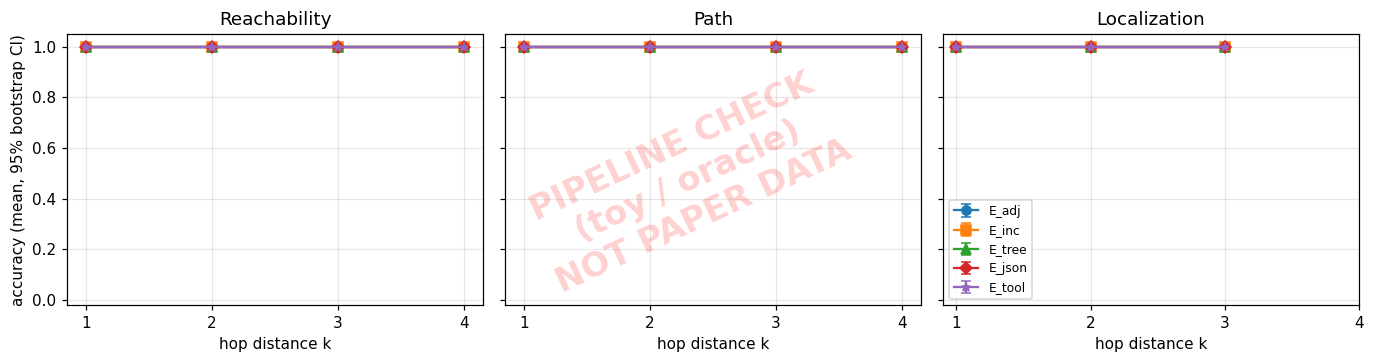

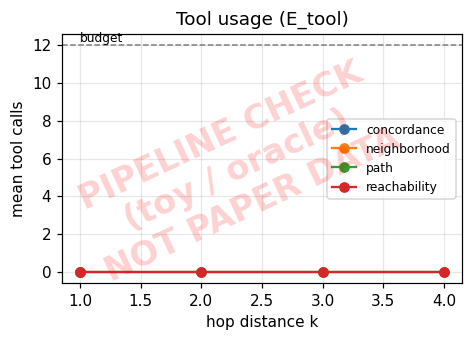

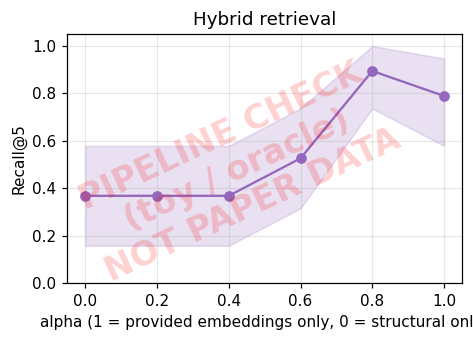

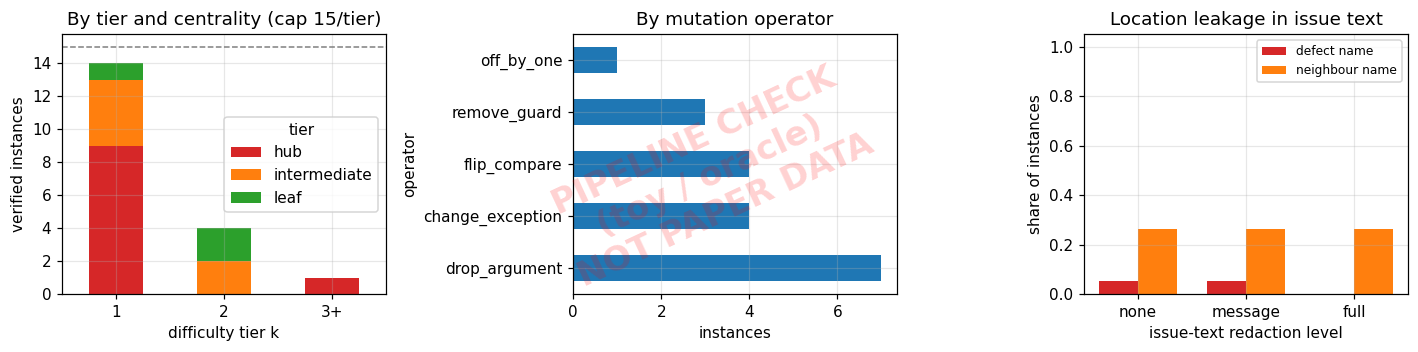

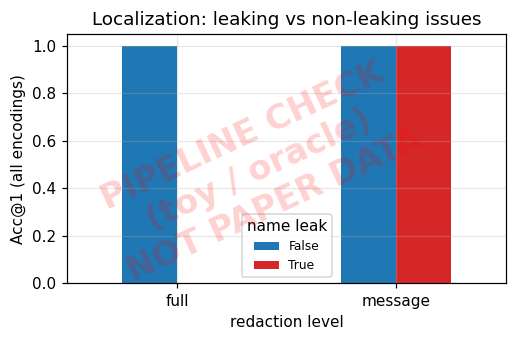

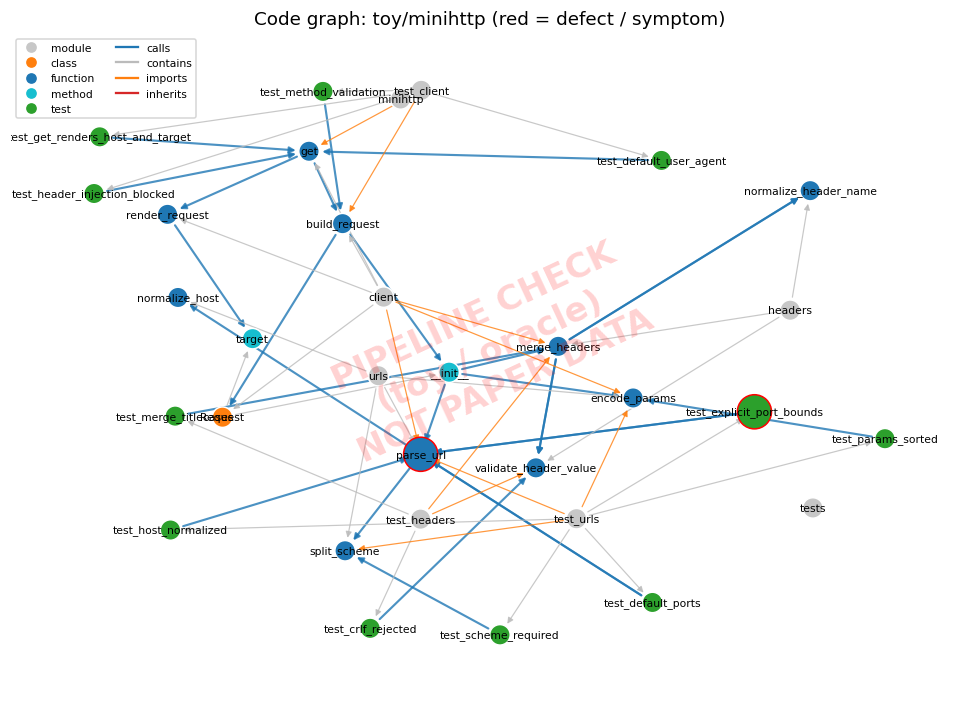

Figures saved: ['fig_accuracy_by_hop.pdf', 'fig_accuracy_by_hop.png', 'fig_alpha_sweep.pdf', 'fig_alpha_sweep.png', 'fig_code_graph.pdf', 'fig_code_graph.png', 'fig_graphsmith_distribution.pdf', 'fig_graphsmith_distribution.png', 'fig_localization_leak.pdf', 'fig_localization_leak.png', 'fig_tool_calls.pdf', 'fig_tool_calls.png']


In [20]:
import matplotlib
import matplotlib.pyplot as plt

FIG_DIR = WORK / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
IS_CHECK = MODE == "toy" or BACKEND != "openai_compat"
ENC_STYLE = {"adj": ("#1f77b4", "o"), "inc": ("#ff7f0e", "s"), "tree": ("#2ca02c", "^"),
             "json": ("#d62728", "D"), "tool": ("#9467bd", "*")}
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})

def _finish(fig, name):
    if IS_CHECK:
        fig.text(0.5, 0.5, f"PIPELINE CHECK\n({MODE} / {BACKEND})\nNOT PAPER DATA", ha="center", va="center",
                 fontsize=22, color="red", alpha=0.18, rotation=25, weight="bold")
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", bbox_inches="tight")
    plt.show()
    plt.close(fig)

# --- Fig A: accuracy vs hop distance, per encoding (H1/H2) -------------------
def fig_accuracy_by_hop(res):
    fams = [f for f in ["reachability", "path", "localization"] if f in set(res.family)]
    if not fams:
        return
    fig, axes = plt.subplots(1, len(fams), figsize=(4.2 * len(fams), 3.4), sharey=True, squeeze=False)
    for ax, fam in zip(axes[0], fams):
        sub = res[(res.family == fam) & res.k.notna()]
        for enc in ENCODINGS:
            e = sub[sub.encoding == enc]
            if e.empty:
                continue
            ks = sorted(e.k.unique())
            means = [e[e.k == k]["score"].mean() for k in ks]
            cis = [boot_ci(e[e.k == k]["score"]) for k in ks]
            lo = [m - c[0] for m, c in zip(means, cis)]; hi = [c[1] - m for m, c in zip(means, cis)]
            col, mk = ENC_STYLE[enc]
            ax.errorbar(ks, means, yerr=[lo, hi], label=f"E_{enc}", color=col, marker=mk, capsize=3, lw=1.5)
        ax.set_title(fam.capitalize()); ax.set_xlabel("hop distance k"); ax.set_ylim(-0.02, 1.05)
        ax.set_xticks(HOPS)
    axes[0][0].set_ylabel("accuracy (mean, 95% bootstrap CI)")
    axes[0][-1].legend(fontsize=8, loc="lower left")
    _finish(fig, "fig_accuracy_by_hop")

# --- Fig B: tool calls used by E_tool vs k -----------------------------------
def fig_tool_calls(res):
    t = res[(res.encoding == "tool") & res.k.notna()]
    if t.empty:
        return
    fig, ax = plt.subplots(figsize=(4.4, 3.2))
    for fam, g in t.groupby("family"):
        m = g.groupby("k")["tool_calls"].mean()
        ax.plot(m.index, m.values, marker="o", label=fam)
    ax.axhline(TOOL_BUDGET, ls="--", color="grey", lw=1); ax.text(HOPS[0], TOOL_BUDGET + 0.2, "budget", fontsize=8)
    ax.set_xlabel("hop distance k"); ax.set_ylabel("mean tool calls"); ax.set_title("Tool usage (E_tool)")
    ax.legend(fontsize=8)
    _finish(fig, "fig_tool_calls")

# --- Fig C: hybrid retrieval alpha sweep (H4) ---------------------------------
def fig_alpha_sweep(sweep):
    if sweep is None or sweep.empty:
        return
    g = sweep.groupby("alpha")["recall5"]
    m = g.mean(); ci = [boot_ci(sweep[sweep.alpha == a]["recall5"]) for a in m.index]
    fig, ax = plt.subplots(figsize=(4.4, 3.2))
    ax.plot(m.index, m.values, marker="o", color="#9467bd")
    ax.fill_between(m.index, [c[0] for c in ci], [c[1] for c in ci], alpha=0.2, color="#9467bd")
    ax.set_xlabel("alpha (1 = provided embeddings only, 0 = structural only)")
    ax.set_ylabel("Recall@5"); ax.set_ylim(0, 1.05); ax.set_title("Hybrid retrieval")
    _finish(fig, "fig_alpha_sweep")

# --- Fig D: GraphSmith instance distribution ----------------------------------
def fig_graphsmith(gs):
    if not gs:
        return
    df = pd.DataFrame(gs)
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
    ct = pd.crosstab(df["k_bin"], df["tier"]).reindex(columns=["hub", "intermediate", "leaf"], fill_value=0)
    ct = ct.reindex(sorted(GS_TIER_CAP), fill_value=0)
    ct.index = [f"{k}" if k < 3 else "3+" for k in ct.index]
    ct.plot(kind="bar", stacked=True, ax=axes[0], color=["#d62728", "#ff7f0e", "#2ca02c"], rot=0)
    cap = max(GS_TIER_CAP.values())
    axes[0].axhline(cap, ls="--", color="grey", lw=1)
    axes[0].set_xlabel("difficulty tier k"); axes[0].set_ylabel("verified instances")
    axes[0].set_title(f"By tier and centrality (cap {cap}/tier)")
    df["operator"].value_counts().plot(kind="barh", ax=axes[1], color="#1f77b4")
    axes[1].set_xlabel("instances"); axes[1].set_title("By mutation operator")
    levels = ["none", "message", "full"]
    name_rate = [df["name_leak"].map(lambda d: d[l]).mean() for l in levels]
    nb_rate = [df["neighbor_leak"].map(lambda d: d[l]).mean() for l in levels]
    x = np.arange(len(levels))
    axes[2].bar(x - 0.18, name_rate, 0.36, label="defect name", color="#d62728")
    axes[2].bar(x + 0.18, nb_rate, 0.36, label="neighbour name", color="#ff7f0e")
    axes[2].set_xticks(x, levels); axes[2].set_ylim(0, 1.05)
    axes[2].set_xlabel("issue-text redaction level"); axes[2].set_ylabel("share of instances")
    axes[2].set_title("Location leakage in issue text"); axes[2].legend(fontsize=8)
    _finish(fig, "fig_graphsmith_distribution")

def fig_localization_leak(table):
    if table is None or table.empty:
        return
    t = table.groupby(["redaction", "name_leak"])["acc1"].mean().unstack("name_leak")
    fig, ax = plt.subplots(figsize=(4.8, 3.2))
    t.plot(kind="bar", ax=ax, rot=0, color={False: "#1f77b4", True: "#d62728"})
    ax.set_ylim(0, 1.05); ax.set_xlabel("redaction level"); ax.set_ylabel("Acc@1 (all encodings)")
    ax.set_title("Localization: leaking vs non-leaking issues")
    ax.legend(title="name leak", fontsize=8)
    _finish(fig, "fig_localization_leak")

# --- Fig E: code graph snapshot ----------------------------------------------
KIND_COLOR = {"module": "#c7c7c7", "class": "#ff7f0e", "function": "#1f77b4", "method": "#17becf",
              "test": "#2ca02c", "symbol": "#1f77b4"}
EDGE_COLOR = {"calls": "#1f77b4", "contains": "#bbbbbb", "imports": "#ff7f0e", "inherits": "#d62728"}

def fig_code_graph(repo_key, max_nodes=60, highlight=None):
    G = CORPUS[repo_key]["G"]
    nodes = list(G.nodes())
    if len(nodes) > max_nodes:   # keep the densest region
        core = max(nodes, key=G.degree)
        nodes = focus_subgraph(G, [core], 3)[:max_nodes]
    H = G.subgraph(nodes)
    pos = nx.spring_layout(nx.Graph(H), seed=1, k=0.9)
    fig, ax = plt.subplots(figsize=(9, 6.5))
    for et, col in EDGE_COLOR.items():
        es = [(u, v) for u, v, d in H.edges(data=True) if d["type"] == et]
        nx.draw_networkx_edges(H, pos, edgelist=es, edge_color=col, ax=ax, arrows=True, arrowsize=8,
                               width=1.4 if et == "calls" else 0.8, alpha=0.8, label=et)
    cols = [KIND_COLOR.get(H.nodes[n]["kind"], "#999") for n in H]
    sizes = [500 if highlight and n in highlight else 180 for n in H]
    nx.draw_networkx_nodes(H, pos, node_color=cols, node_size=sizes, ax=ax,
                           edgecolors=["red" if highlight and n in highlight else "white" for n in H])
    nx.draw_networkx_labels(H, pos, {n: H.nodes[n]["name"] for n in H}, font_size=7, ax=ax)
    handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=k) for k, c in KIND_COLOR.items() if k != "symbol"]
    handles += [plt.Line2D([], [], color=c, label=e) for e, c in EDGE_COLOR.items()]
    ax.legend(handles=handles, fontsize=7, loc="upper left", ncol=2); ax.set_axis_off()
    ax.set_title(f"Code graph: {repo_key}" + (" (red = defect / symptom)" if highlight else ""))
    _finish(fig, "fig_code_graph")

fig_accuracy_by_hop(pd.concat([RESULTS, globals()["loc_res"]]) if "loc_res" in globals() else RESULTS)
fig_tool_calls(RESULTS)
fig_alpha_sweep(globals().get("SWEEP"))
fig_graphsmith(GS)
fig_localization_leak(globals().get("LEAK_TABLE"))
first_repo = next(iter(CORPUS))
fig_code_graph(first_repo, highlight={GS[0]["defect"], GS[0]["symptom"]} if GS else None)
print("Figures saved:", sorted(p.name for p in FIG_DIR.iterdir()))

## 15. Save everything & download
Collects results CSVs, LaTeX tables, figures, the dataset export and the data card into one zip.
* **Colab:** the browser download starts automatically.
* **Kaggle:** files in `/kaggle/working` appear under *Output* after *Save Version*; a download link is also shown.
* **Local Jupyter:** a clickable link is shown.

In [21]:
# summary tables as CSV (easy to paste into the paper)
RESULTS.groupby(["family", "encoding", "k"])["score"].agg(["mean", "count"]).reset_index() \
    .to_csv(WORK / f"summary_by_hop_{MODE}_{BACKEND}.csv", index=False)
if "loc_res_all" in globals():
    loc_res_all.to_csv(WORK / f"graphsmith_localization_{MODE}_{BACKEND}.csv", index=False)
    LEAK_TABLE.to_csv(WORK / f"graphsmith_leak_table_{MODE}_{BACKEND}.csv", index=False)
if GS:
    _g = pd.DataFrame(GS).drop(columns=["buggy_file", "issue_variants", "bug_patch", "fix_patch"])
    for lvl in ("none", "message", "full"):
        _g[f"name_leak_{lvl}"] = _g["name_leak"].map(lambda d: d[lvl])
        _g[f"neighbor_leak_{lvl}"] = _g["neighbor_leak"].map(lambda d: d[lvl])
    _g.drop(columns=["name_leak", "neighbor_leak", "leaked_names", "leaked_neighbors"]).to_csv(
        WORK / f"graphsmith_instances_{MODE}.csv", index=False)
(WORK / "RUN_INFO.json").write_text(json.dumps({
    "mode": MODE, "backend": BACKEND, "model": MODEL_ID, "seeds": SEEDS, "hops": HOPS,
    "n_per_stratum": N_PER_STRATUM, "token_budget": TOKEN_BUDGET, "tool_budget": TOOL_BUDGET,
    "n_questions": len(QA), "n_graphsmith": len(GS),
    "graphsmith_tier_cap": GS_TIER_CAP, "graphsmith_max_candidates": GRAPHSMITH_MAX_CANDIDATES,
    "graphsmith_log": dict(globals().get("gs_log", {})), "issue_redaction": ISSUE_REDACTION, "pipeline_check_only": IS_CHECK,
    "created": time.strftime("%Y-%m-%d %H:%M:%S"), "python": sys.version.split()[0],
    "networkx": nx.__version__, "numpy": np.__version__, "pandas": pd.__version__}, indent=2))

bundle_name = f"codegraph_results_{MODE}_{BACKEND}_{time.strftime('%Y%m%d_%H%M')}"
skip = {"toy_repo"}
bundle = WORK / f"{bundle_name}.zip"
with zipfile.ZipFile(bundle, "w", zipfile.ZIP_DEFLATED) as z:
    for p in sorted(WORK.rglob("*")):
        if p.is_file() and p != bundle and not p.name.endswith(".zip") \
                and not p.name.startswith("gs_junit") \
                and not any(part in skip for part in p.relative_to(WORK).parts):
            z.write(p, p.relative_to(WORK))
with zipfile.ZipFile(bundle) as z:
    names = z.namelist()
print(f"Bundle: {bundle}  ({bundle.stat().st_size/1024:.1f} KB, {len(names)} files)")
for n in names:
    print("  ", n)

try:
    from google.colab import files as colab_files       # Colab
    colab_files.download(str(bundle))
    print("Download started (allow pop-ups/multiple downloads if your browser asks).")
except ImportError:
    try:
        from IPython.display import FileLink, display as _d
        if Path("/kaggle/working").exists():
            print("Kaggle: find the zip under Output after 'Save Version', or use the link below.")
        _d(FileLink(os.path.relpath(bundle)))
    except Exception:
        print("Download the file from:", bundle)

Bundle: /content/work/codegraph_results_toy_oracle_20260928_1258.zip  (588.8 KB, 25 files)
   RUN_INFO.json
   alpha_sweep_toy.csv
   dataset_toy/DATA_CARD.md
   dataset_toy/codegraph_qa.jsonl
   dataset_toy/graphsmith.jsonl
   dataset_toy/schema_inventory.json
   figures/fig_accuracy_by_hop.pdf
   figures/fig_accuracy_by_hop.png
   figures/fig_alpha_sweep.pdf
   figures/fig_alpha_sweep.png
   figures/fig_code_graph.pdf
   figures/fig_code_graph.png
   figures/fig_graphsmith_distribution.pdf
   figures/fig_graphsmith_distribution.png
   figures/fig_localization_leak.pdf
   figures/fig_localization_leak.png
   figures/fig_tool_calls.pdf
   figures/fig_tool_calls.png
   graphsmith_instances_toy.csv
   graphsmith_leak_table_toy_oracle.csv
   graphsmith_localization_toy_oracle.csv
   results_toy_oracle.csv
   security_slice.json
   summary_by_hop_toy_oracle.csv
   table_encodings_toy_oracle.tex


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started (allow pop-ups/multiple downloads if your browser asks).


## Next steps
1. Toy mode: run with `BACKEND="oracle"` (must pass the assertion), then `BACKEND="random"`.
2. Attach the competition data, set `MODE="competition"`, check the printed schema inventory, and adjust `graph_file_for_task` / `embedding_files_for_task` if needed.
3. Start vLLM with the competition checkpoint, set `BACKEND="openai_compat"`, and run the full matrix with 3 seeds.
4. Build runnable checkouts (competition Docker image) to run GraphSmith on the real repositories.
5. LoRA fine-tuning on verified GraphSmith trajectories lives in a separate training notebook.
6. Copy numbers from the exported `.tex` files and CSVs into the paper, replacing each red **TBD**; use the PDF figures from `figures/` in the paper.
7. Run section 15 at the end of every real run and keep the zip — it is your record of exactly which settings produced each number.